In [3]:
import torch
from torch_geometric.data import Data
from model import Net, Net_second
from torch_geometric.utils import to_dense_adj
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Overlay helper
def overlay_mask_rgb(img, mask, alpha=0.5, color=(1, 0, 0)):
    """
    img: HxWx3 uint8
    mask: HxW binary
    color: tuple in [0,1] for RGB
    """
    imgf = img.astype(float) / 255.0
    c = np.array(color)[None,None,:]
    mask_bool = mask.astype(bool)
    imgf[mask_bool] = imgf[mask_bool] * (1-alpha) + c * alpha
    return (imgf * 255).astype(np.uint8)

In [201]:
# Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GRAPH_PATH = "/home/iiitb/Desktop/anant/GridRaster/test_processed_data/graph_2.pt"
#MODEL_PATH = "/home/iiitb/Desktop/anant/GridRaster/saved_models/best_model.pth"
MODEL_PATH = "/home/iiitb/Desktop/anant/GridRaster/model_mp_[[1024, 1024], [1024, 1024]]_mlp_[[512, 512], [512, 512]]_AdjLearning_BS32_epoch_500/best_model.pth"
# NUM_CLUSTERS = 2  # Must match training
# MP_UNITS = [64]
# MLP_UNITS = []
MP_ACT = 'ELU'
#MLP_ACT = 'Identity'
MLP_ACT = 'ReLU'
IN_CHANNELS = 1024
NUM_CLUSTERS = 2
MP_UNITS = [[1024, 1024], [1024, 1024]] # a list
MLP_UNITS = [[512, 512], [512, 512]]
#NUM_CLUSTERS = [2]
# MP_UNITS = [[512,256, 128]] # a list
# MLP_UNITS = [[64,32]]
#NUM_CLUSTERS = [2, 2]
#MP_UNITS = [[512,256, 128],[128,64]] # a list
#MLP_UNITS = [[64,32],[32,16]]


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
model = Net_second(
    mp_units=MP_UNITS,
    mp_act=MP_ACT,
    in_channels=IN_CHANNELS,
    n_clusters=NUM_CLUSTERS,
    mlp_units=MLP_UNITS,
    mlp_act=MLP_ACT
).to(DEVICE)

# model = Net_simple(
#     mp_units=MP_UNITS,
#     mp_act=MP_ACT,
#     in_channels=IN_CHANNELS,
#     n_clusters=NUM_CLUSTERS,
#     mlp_units=MLP_UNITS,
#     mlp_act=MLP_ACT
# ).to(DEVICE)


#model = DenseMinCutNet(in_channels=1024, hidden_channels=64, out_clusters=2).to(DEVICE)

model.load_state_dict(torch.load(MODEL_PATH))
model.eval()
print("Loaded model for inference.")

Loaded model for inference.


In [202]:
# Load one graph
data = torch.load(GRAPH_PATH)
data = data.to(DEVICE)

In [203]:
data

Data(x=[31, 1024], edge_index=[2, 961], y=[31], x_part=[11, 1024], batch_part=[11], edge_weight=[961], object_id=13, part_id=111, segments=[224, 224], query_full_superpixels=[31], gt_query_part_superpixels=[12], image=[224, 224])

In [204]:
data.y

tensor([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0], device='cuda:0')

In [205]:
# Forward pass
with torch.no_grad():
    out, _, _ = model(data.x, data.x_part, data.edge_index, data.edge_weight, batch=torch.zeros(data.num_nodes, dtype=torch.long, device=DEVICE), batch_part = data.batch_part)

# with torch.no_grad():
#     out, _, _ = model(data.x, data.edge_index, data.edge_weight, batch=torch.zeros(data.num_nodes, dtype=torch.long, device=DEVICE))

In [206]:
#model.named_parameters

In [207]:
# from torchviz import make_dot
# model = model.to(DEVICE)
# dot = make_dot(out, params=dict(model.named_parameters()))
# #dot.format = 'pdf'  # or 'pdf', 'svg'
# dot.render('model_graph', format='png')

In [208]:
#!pip install torchview


# from torchview import draw_graph
# graph = draw_graph(model, input_data=(data.x, data.x_part, data.edge_index, data.edge_weight, data.batch, data.batch_part),
#                    expand_nested=True)
# graph.visual_graph.render("gnn_layer_graph", format="png")


In [209]:
# Get predicted cluster for each node (superpixel)
predicted = out.argmax(dim=1).cpu().numpy()
print(f"Predicted cluster labels (per superpixel):\n{predicted}")

Predicted cluster labels (per superpixel):
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [210]:
segments = data.segments.cpu().numpy()                      # 2D label map of superpixels
query_full_superpixels = data.query_full_superpixels.cpu().numpy()  # list of superpixel IDs used

# id_map: superpixel ID → prediction label
id_map = {sp_id: predicted[i] for i, sp_id in enumerate(query_full_superpixels)}

# Reconstruct predicted mask
pred_mask = np.zeros_like(segments, dtype=np.uint8)
for sp_id, label in id_map.items():
    pred_mask[segments == sp_id] = label


gt_query_part_superpixels = data.gt_query_part_superpixels.cpu().numpy()
# Ground Truth Part Mask
gt_mask = np.isin(segments, gt_query_part_superpixels).astype(np.uint8)

print(f"query full superpixels number: {query_full_superpixels} and count {len(query_full_superpixels)} | query part superpixels number {gt_query_part_superpixels} and count {len(gt_query_part_superpixels)}")

# Retrieve and prepare image
img_t = data.image  # shape [H, W]
img_np = img_t.cpu().numpy()

# If single channel, convert to RGB
if img_np.ndim == 2:
    img_gray = img_np
    img_rgb = np.stack([img_gray]*3, axis=-1)  # [H, W, 3]
else:
    # If it's [C, H, W], permute to [H, W, C]
    img_rgb = img_np.transpose(1, 2, 0)
    # If normalized in [0,1], scale to [0,255]:
    if img_rgb.max() <= 1.0:
        img_rgb = (img_rgb * 255).astype(np.uint8)


query full superpixels number: [305 306 333 334 360 361 362 363 388 389 390 391 414 415 416 417 418 442
 443 444 445 471 472 497 498 499 500 525 526 527 528] and count 31 | query part superpixels number [305 333 334 360 361 362 363 388 389 390 391 417] and count 12


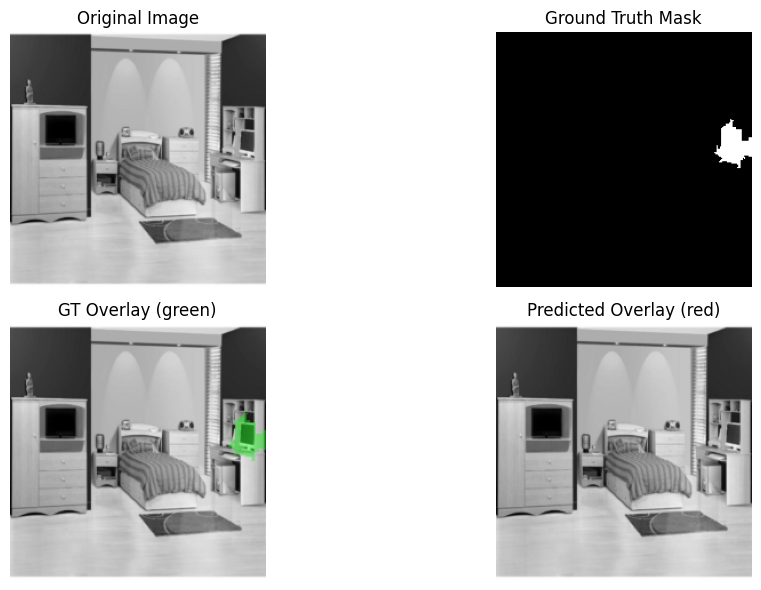

In [211]:
# Create overlays
gt_overlay = overlay_mask_rgb(img_rgb, gt_mask, alpha=0.4, color=(0,1,0))
pred_overlay = overlay_mask_rgb(img_rgb, pred_mask, alpha=0.4, color=(1,0,0))

# Plot
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(gt_mask, cmap='gray')
plt.title("Ground Truth Mask")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(gt_overlay)
plt.title("GT Overlay (green)")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(pred_overlay)
plt.title("Predicted Overlay (red)")
plt.axis('off')

plt.tight_layout()
plt.show()

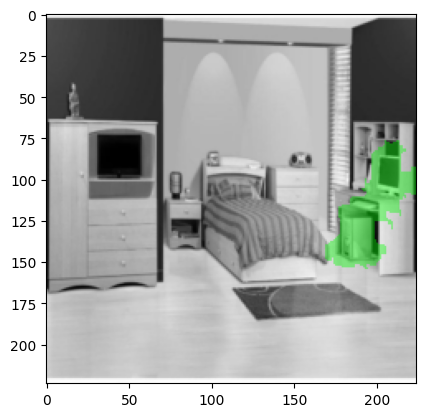

In [212]:
gt_full_mask = np.isin(segments, query_full_superpixels).astype(np.uint8)
gt_full_overlay = overlay_mask_rgb(img_rgb, gt_full_mask, alpha=0.4, color=(0,1,0))
plt.imshow(gt_full_overlay)

In [213]:
from evaluator.evaluator import SimplePartSegEvaluator
evaluator = SimplePartSegEvaluator()

evaluator.process({
                'part_id': data.part_id,
                'gt_mask': torch.tensor(gt_mask),
                'pred_mask': torch.tensor(pred_mask)
            })

evaluator.evaluate()


Per-Part Evaluation (mIoU):

Part ID 111: mIoU = 0.0000 (n=1)

Overall mIoU across parts: 0.0000


defaultdict(list, {111: [0.0]})